# CREDIT  RISK MODELLING 

# 1. Setting the Background
The most pressing questions for banks are how efficiently can we guage the risk profile of our customers and how can we use this information to decide on the required liquidity while still maintaining our regulatory obligations. 

With the constantly changing customer portfolio and the ever increasing customer base a more robust non-hardcoded approach is neccessary to achieve these antagonistic goals. 

Thus comes the idea of using machine learning to develop a behavioural scorecard to pull data from both internal sources, customer transactions and their demographic data, to predict the probability of default. 

In this notebook we are going to explore the data cleaning and transformation as well as machine learing modelling in predicting probability of default. We can then use these results to develop a credit rating. 

We will eplore the following concepts in the notebook
1. Data cleaning - Struucturing the data for modelling 
2. What to do with missing values 
3. How to deal with class imbalance and the implications. 


# 2. Libraries and Data Import

In [1]:
# Impoting general libraries
import warnings
warnings.filterwarnings('ignore')# Ignore warnings

import itertools
import random

# Data manipulation
import pandas as pd
import numpy as np
import missingno as mn

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder,RobustScaler,MinMaxScaler,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

In [2]:
#Loading data 
Loan = pd.read_csv("raw-data.csv")
Loan.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32
0,1,0,0,24.0,0.0,2432.0,46500.0,24.0,1385.0,SC,...,NaN,NaN,46500.0,NaN,NaN,0,0,0,TIER 1,0
1,2,0,1,24.0,1.0,1495.0,28168.0,24.0,2496.0,MO,...,NaN,NaN,28168.0,NaN,NaN,0,0,0,TIER 1,0
2,3,0,0,26.0,0.0,1707.0,38900.0,30.0,1346.0,SC,...,NaN,105000.0,38900.0,34.0,31.0,31,31,16,TIER 1,0
3,4,0,0,24.0,0.0,2128.0,42900.0,24.0,1375.0,SC,...,NaN,NaN,42900.0,NaN,NaN,0,0,0,TIER 1,0
4,5,0,0,27.0,0.0,1824.0,40900.0,30.0,4140.0,MC,...,NaN,NaN,40900.0,NaN,NaN,0,0,0,TIER 1,0


In [3]:
#Renaming columns in the dataset with their correct names
Loan_renamed = Loan.rename(columns={'V1': 'Customer ID',
'V2': 'Customer has bounced in first EMI', 
'V3': 'No of times bounced 12 months',
'V4': 'Maximum MOB',
'V5': 'No of times bounced while repaying the loan',
'V6': 'EMI',
'V7': 'Loan Amount',
'V8': 'Tenure',
'V9': 'Dealer codes from where customer has purchased the Two wheeler',
'V10': 'Product code of Two wheeler', 
'V11': 'No of advance EMI paid',
'V12': 'Rate of interest',
'V13': 'Gender',
'V14': 'Employment type',
'V15': 'Resident type of customer',
'V16': 'Date of birth',
'V17': 'Customer age when loanwas taken',
'V18': 'No of loans',
'V19': 'No of secured loans',
'V20': 'No of unsecured loans',
'V21': 'Max amount sanctioned in the Live loans',
'V22': 'No of new loans in last 3 months',
'V23': 'Total sanctioned amount in the secured Loans which are Live',
'V24': 'Total sanctioned amount in the unsecured Loans which are Live',
'V25': 'Maximum amount sanctioned for any Two wheeler loan',
'V26': 'Time since last Personal loan taken (in months)',
'V27': 'Time since first consumer durables loan taken (in months)',
'V28': 'No of times 30 days past due in last 6 months',
'V29': 'No of times 60 days past due in last 6 months',
'V30': 'No of times 90 days past due in last 3 months',
'V31': 'Tier',
'V32': 'Target variable'})
Loan_renamed.head(2)

,Customer ID,Customer has bounced in first EMI,No of times bounced 12 months,Maximum MOB,No of times bounced while repaying the loan,EMI,Loan Amount,Tenure,Dealer codes from where customer has purchased the Two wheeler,Product code of Two wheeler,...,Total sanctioned amount in the secured Loans which are Live,Total sanctioned amount in the unsecured Loans which are Live,Maximum amount sanctioned for any Two wheeler loan,Time since last Personal loan taken (in months),Time since first consumer durables loan taken (in months),No of times 30 days past due in last 6 months,No of times 60 days past due in last 6 months,No of times 90 days past due in last 3 months,Tier,Target variable
0,1,0,0,24.0,0.0,2432.0,46500.0,24.0,1385.0,SC,...,NaN,NaN,46500.0,NaN,NaN,0,0,0,TIER 1,0
1,2,0,1,24.0,1.0,1495.0,28168.0,24.0,2496.0,MO,...,NaN,NaN,28168.0,NaN,NaN,0,0,0,TIER 1,0


# 3. Basic EDA and Data Cleaning

In [4]:
Loan_renamed.info()

<class 'pandas.DataFrame'>
RangeIndex: 119528 entries, 0 to 119527
Data columns (total 32 columns):
 #   Column                                                          Non-Null Count   Dtype  
---  ------                                                          --------------   -----  
 0   Customer ID                                                     119528 non-null  int64  
 1   Customer has bounced in first EMI                               119528 non-null  int64  
 2   No of times bounced 12 months                                   119528 non-null  int64  
 3   Maximum MOB                                                     85048 non-null   float64
 4   No of times bounced while repaying the loan                     85048 non-null   float64
 5   EMI                                                             85048 non-null   float64
 6   Loan Amount                                                     85048 non-null   float64
 7   Tenure                                           

#### 3.2 Exploring Missingnes

<Axes: >

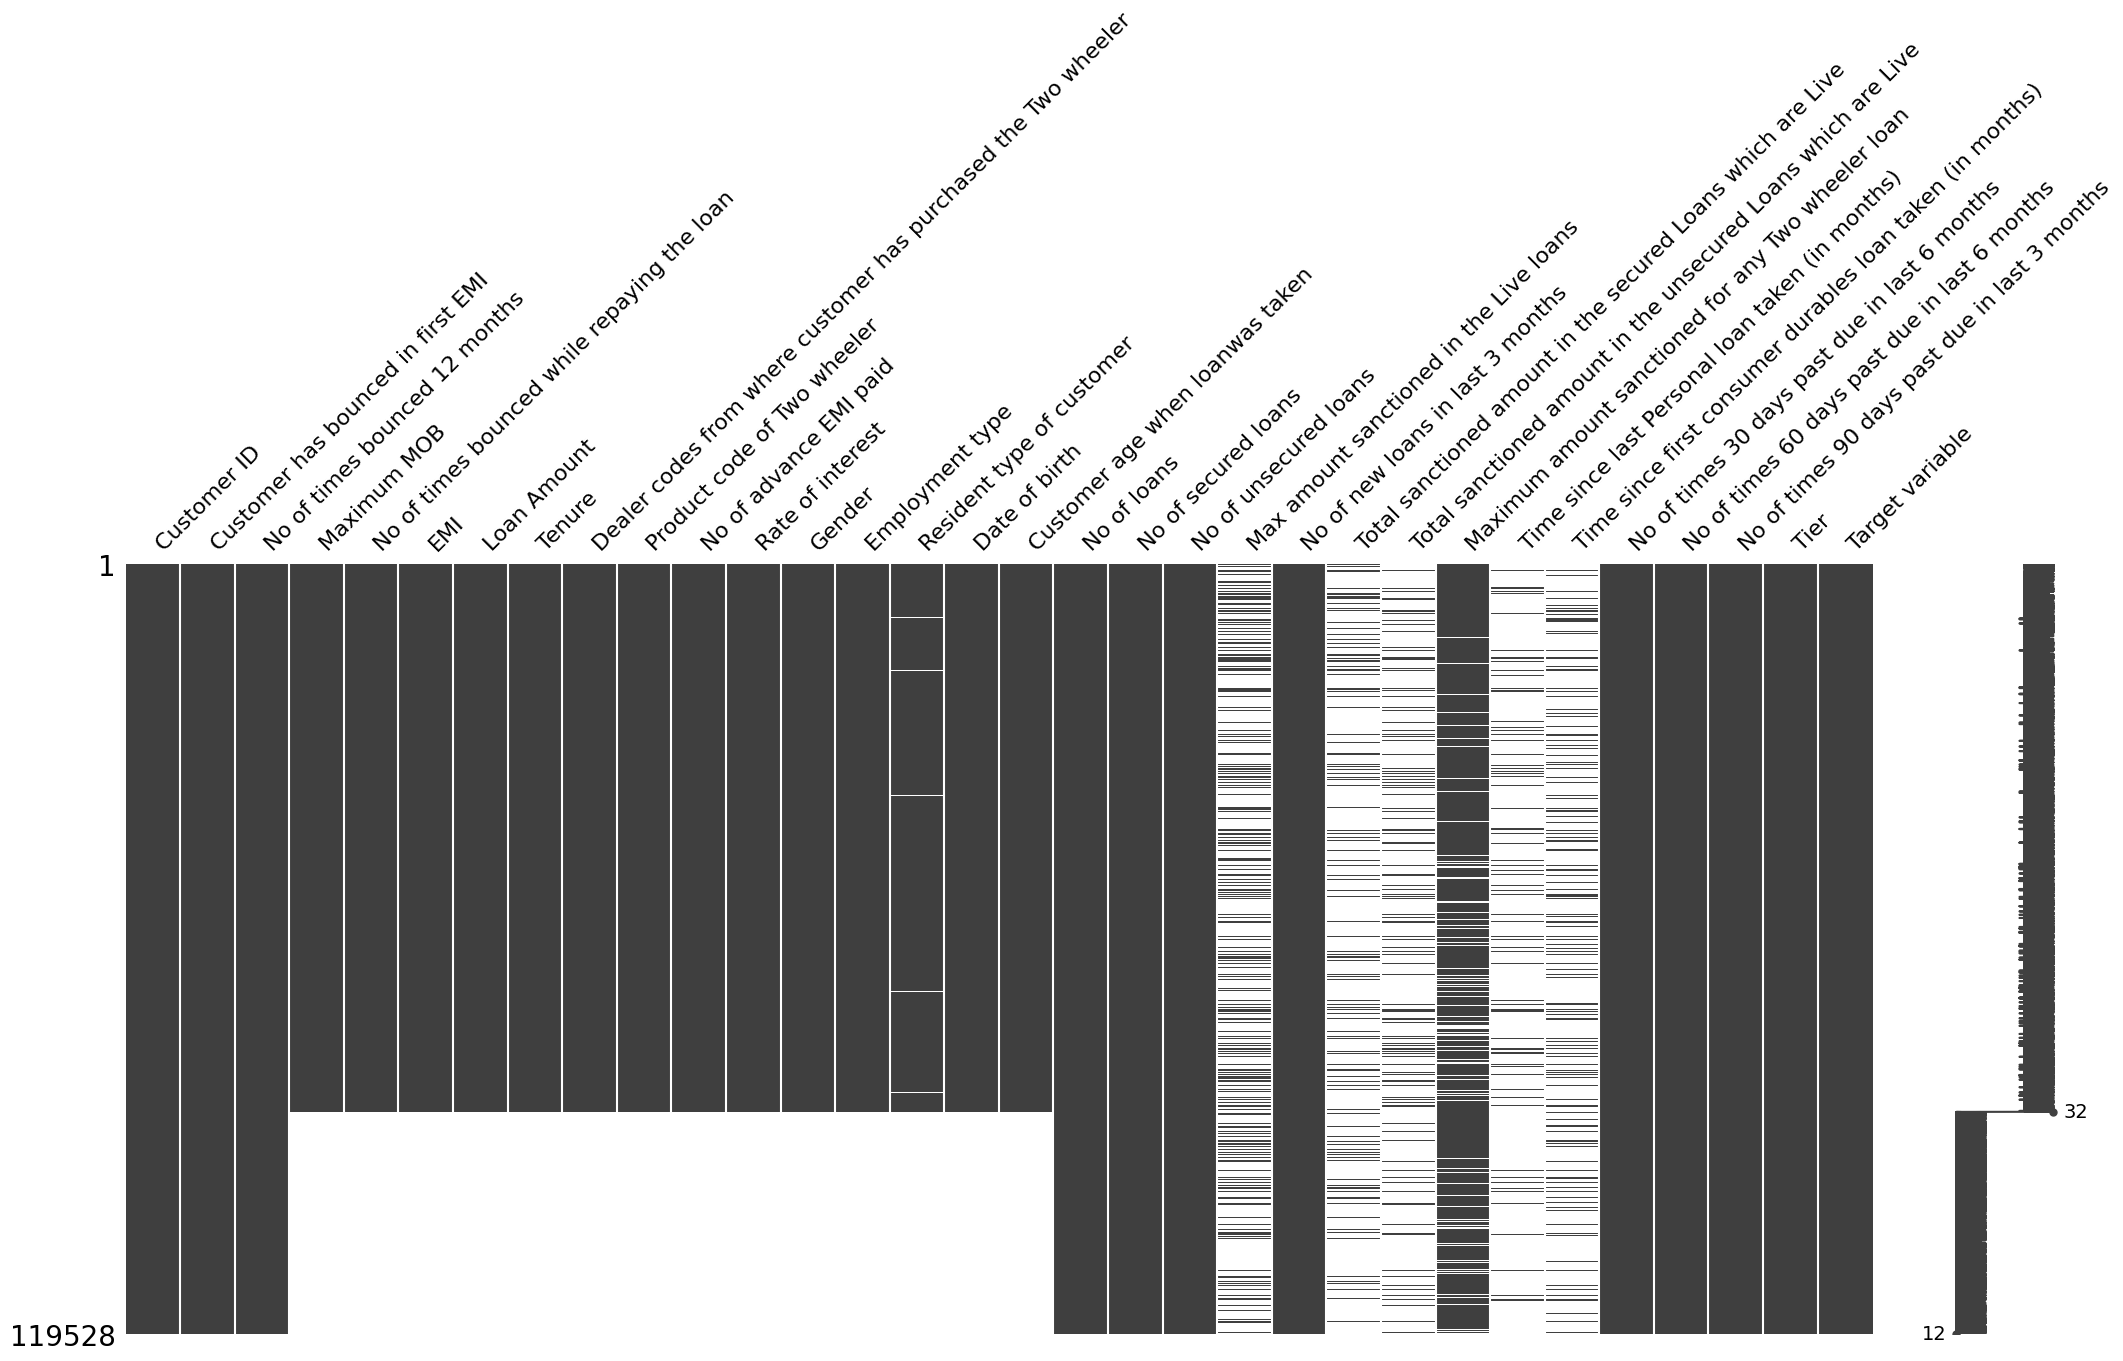

In [5]:
mn.matrix(Loan_renamed)

In [6]:
# Missing values treatment, drops any row with missing values in the loan and gender column
Loan_renamed.dropna(axis=0,how='any',subset=['Loan Amount','Gender'],inplace=True)

In [7]:
#Removing irrelevant columns
Loan_renamed.drop('Customer ID', axis = 1, inplace = True)
Loan_renamed.shape

(85048, 31)

<Axes: >

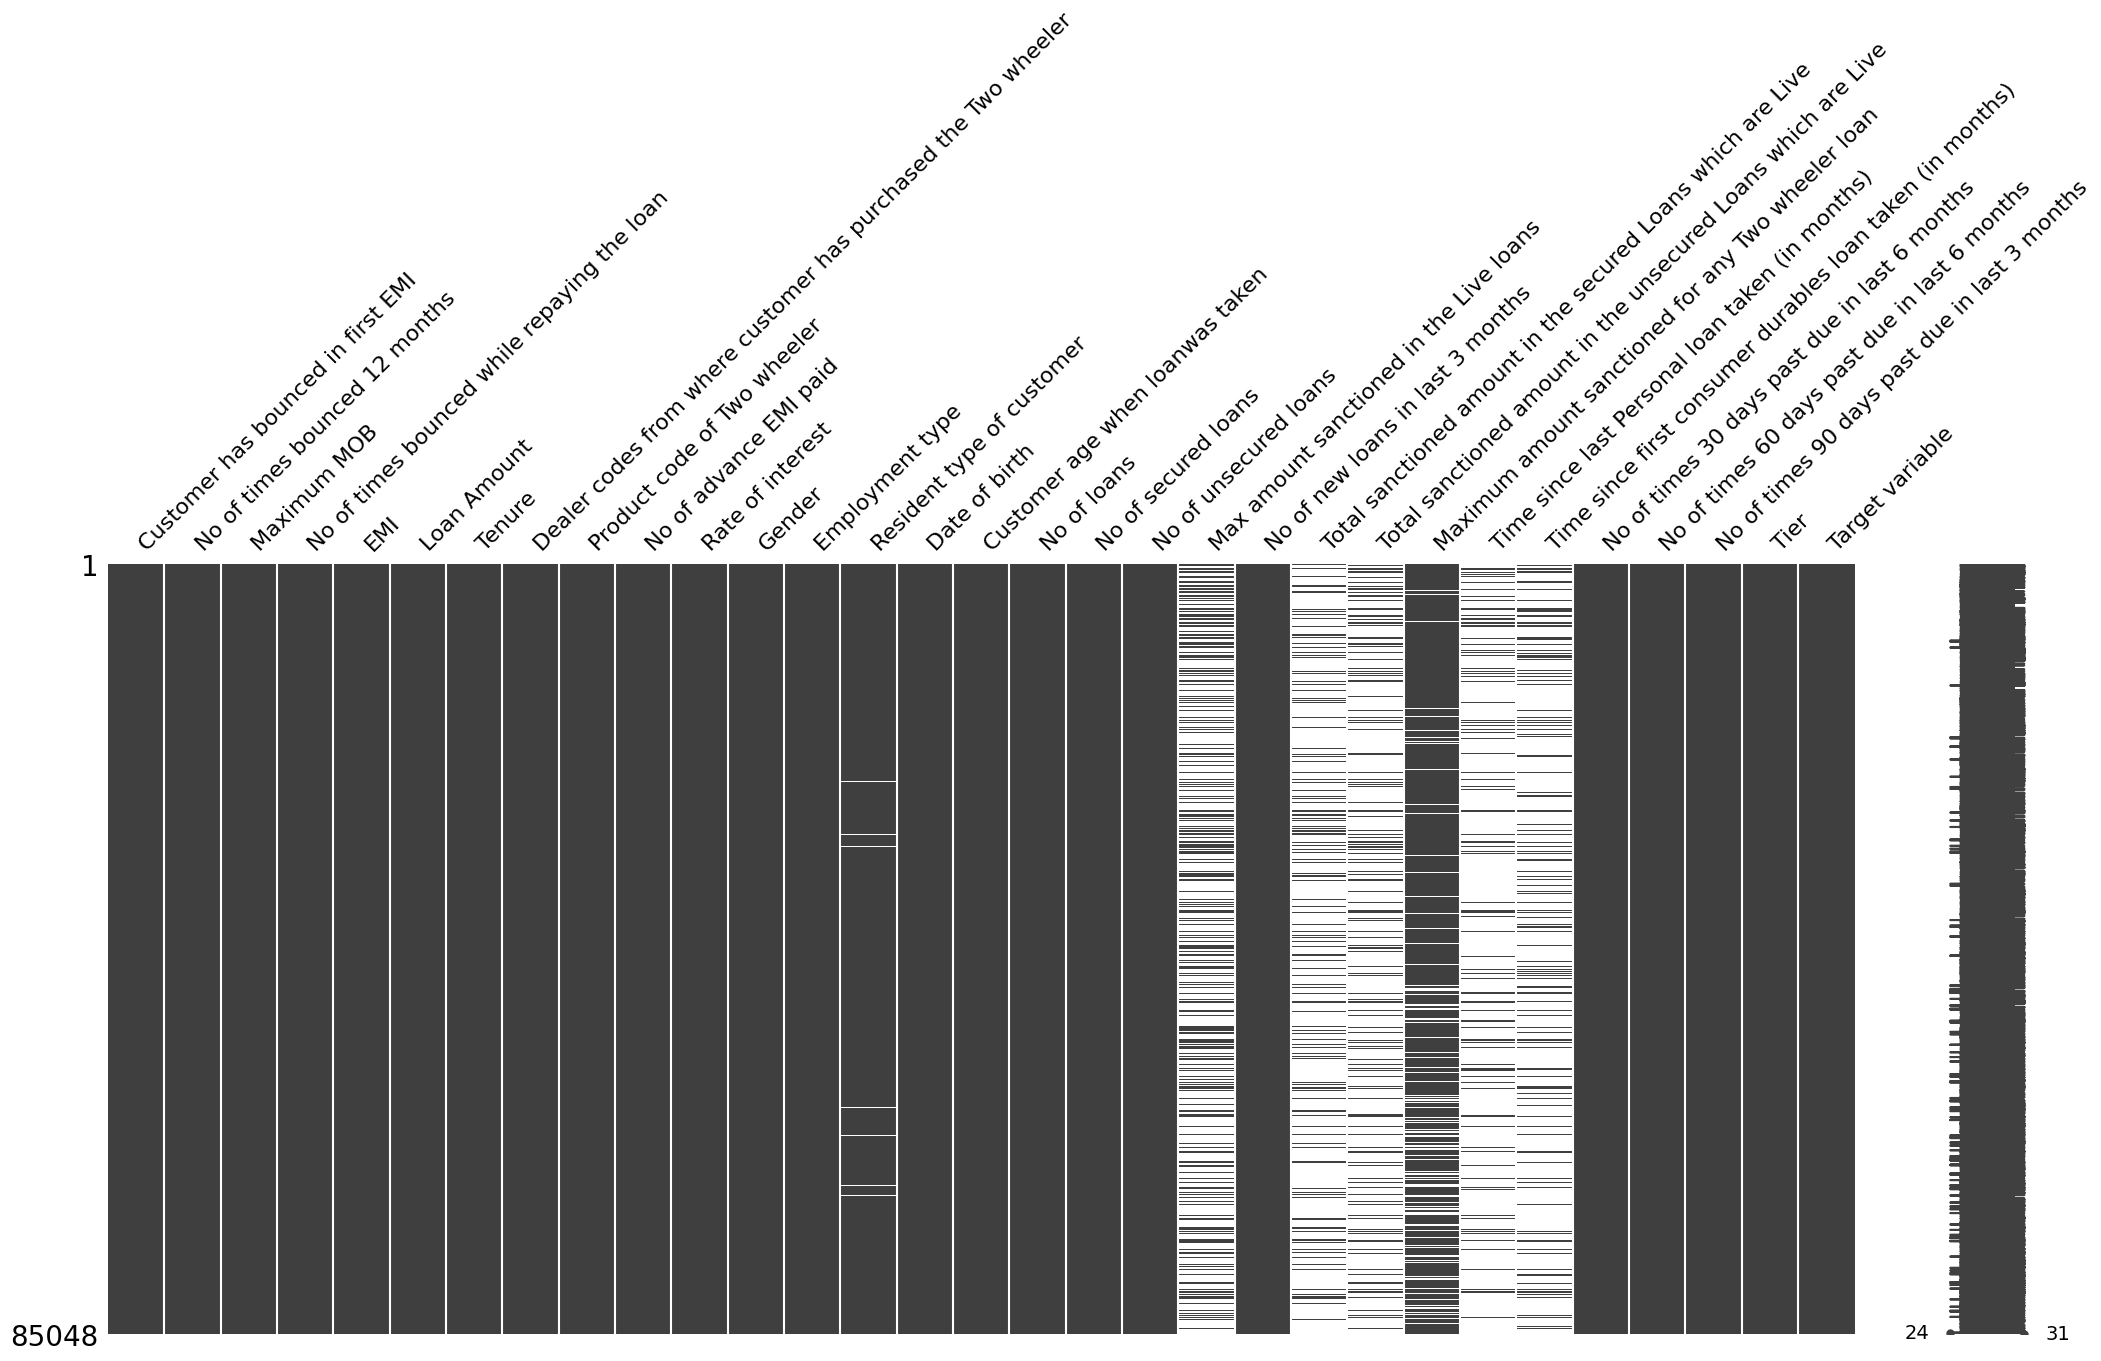

In [8]:
mn.matrix(Loan_renamed)

In [9]:
Loan_renamed.info()

<class 'pandas.DataFrame'>
RangeIndex: 85048 entries, 0 to 85047
Data columns (total 31 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Customer has bounced in first EMI                               85048 non-null  int64  
 1   No of times bounced 12 months                                   85048 non-null  int64  
 2   Maximum MOB                                                     85048 non-null  float64
 3   No of times bounced while repaying the loan                     85048 non-null  float64
 4   EMI                                                             85048 non-null  float64
 5   Loan Amount                                                     85048 non-null  float64
 6   Tenure                                                          85048 non-null  float64
 7   Dealer codes from where customer has purchased the Two wheel

## 4.Visualizations

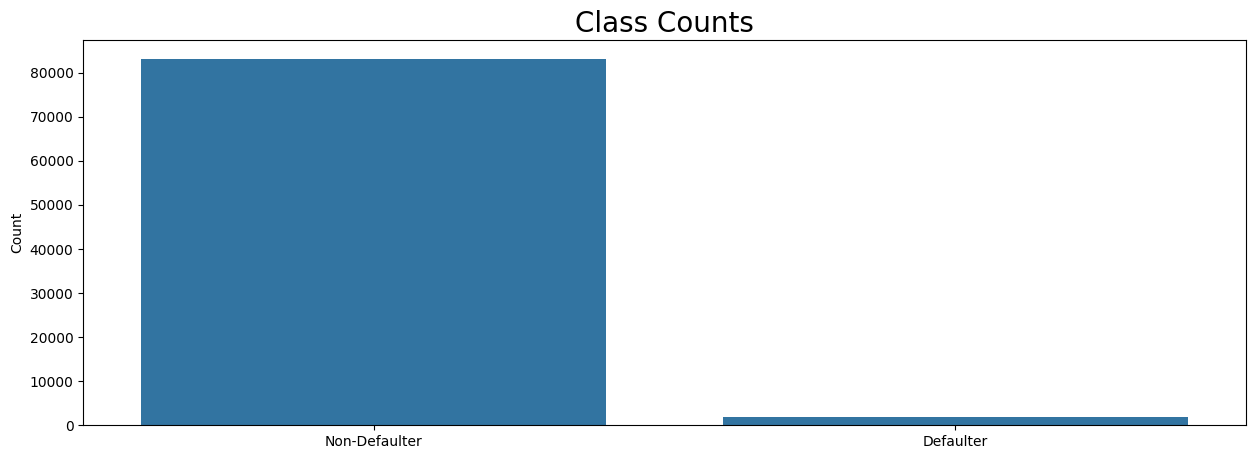

Target variable
0    83194
1     1854
Name: count, dtype: int64


In [10]:
#Defaulters vs Non Defaulters
plt.figure(figsize=(15,5))

sns.countplot(data=Loan_renamed, x='Target variable')

plt.xticks([0, 1], ["Non-Defaulter", "Defaulter"])
plt.xlabel("")
plt.ylabel("Count")
plt.title("Class Counts", fontsize=20)

plt.show()

print(Loan_renamed['Target variable'].value_counts())

This is a binary class classisfication and the data is imbalanced.Non defaulters are higher than the defaulters therefore prompting us to do SMOTE.

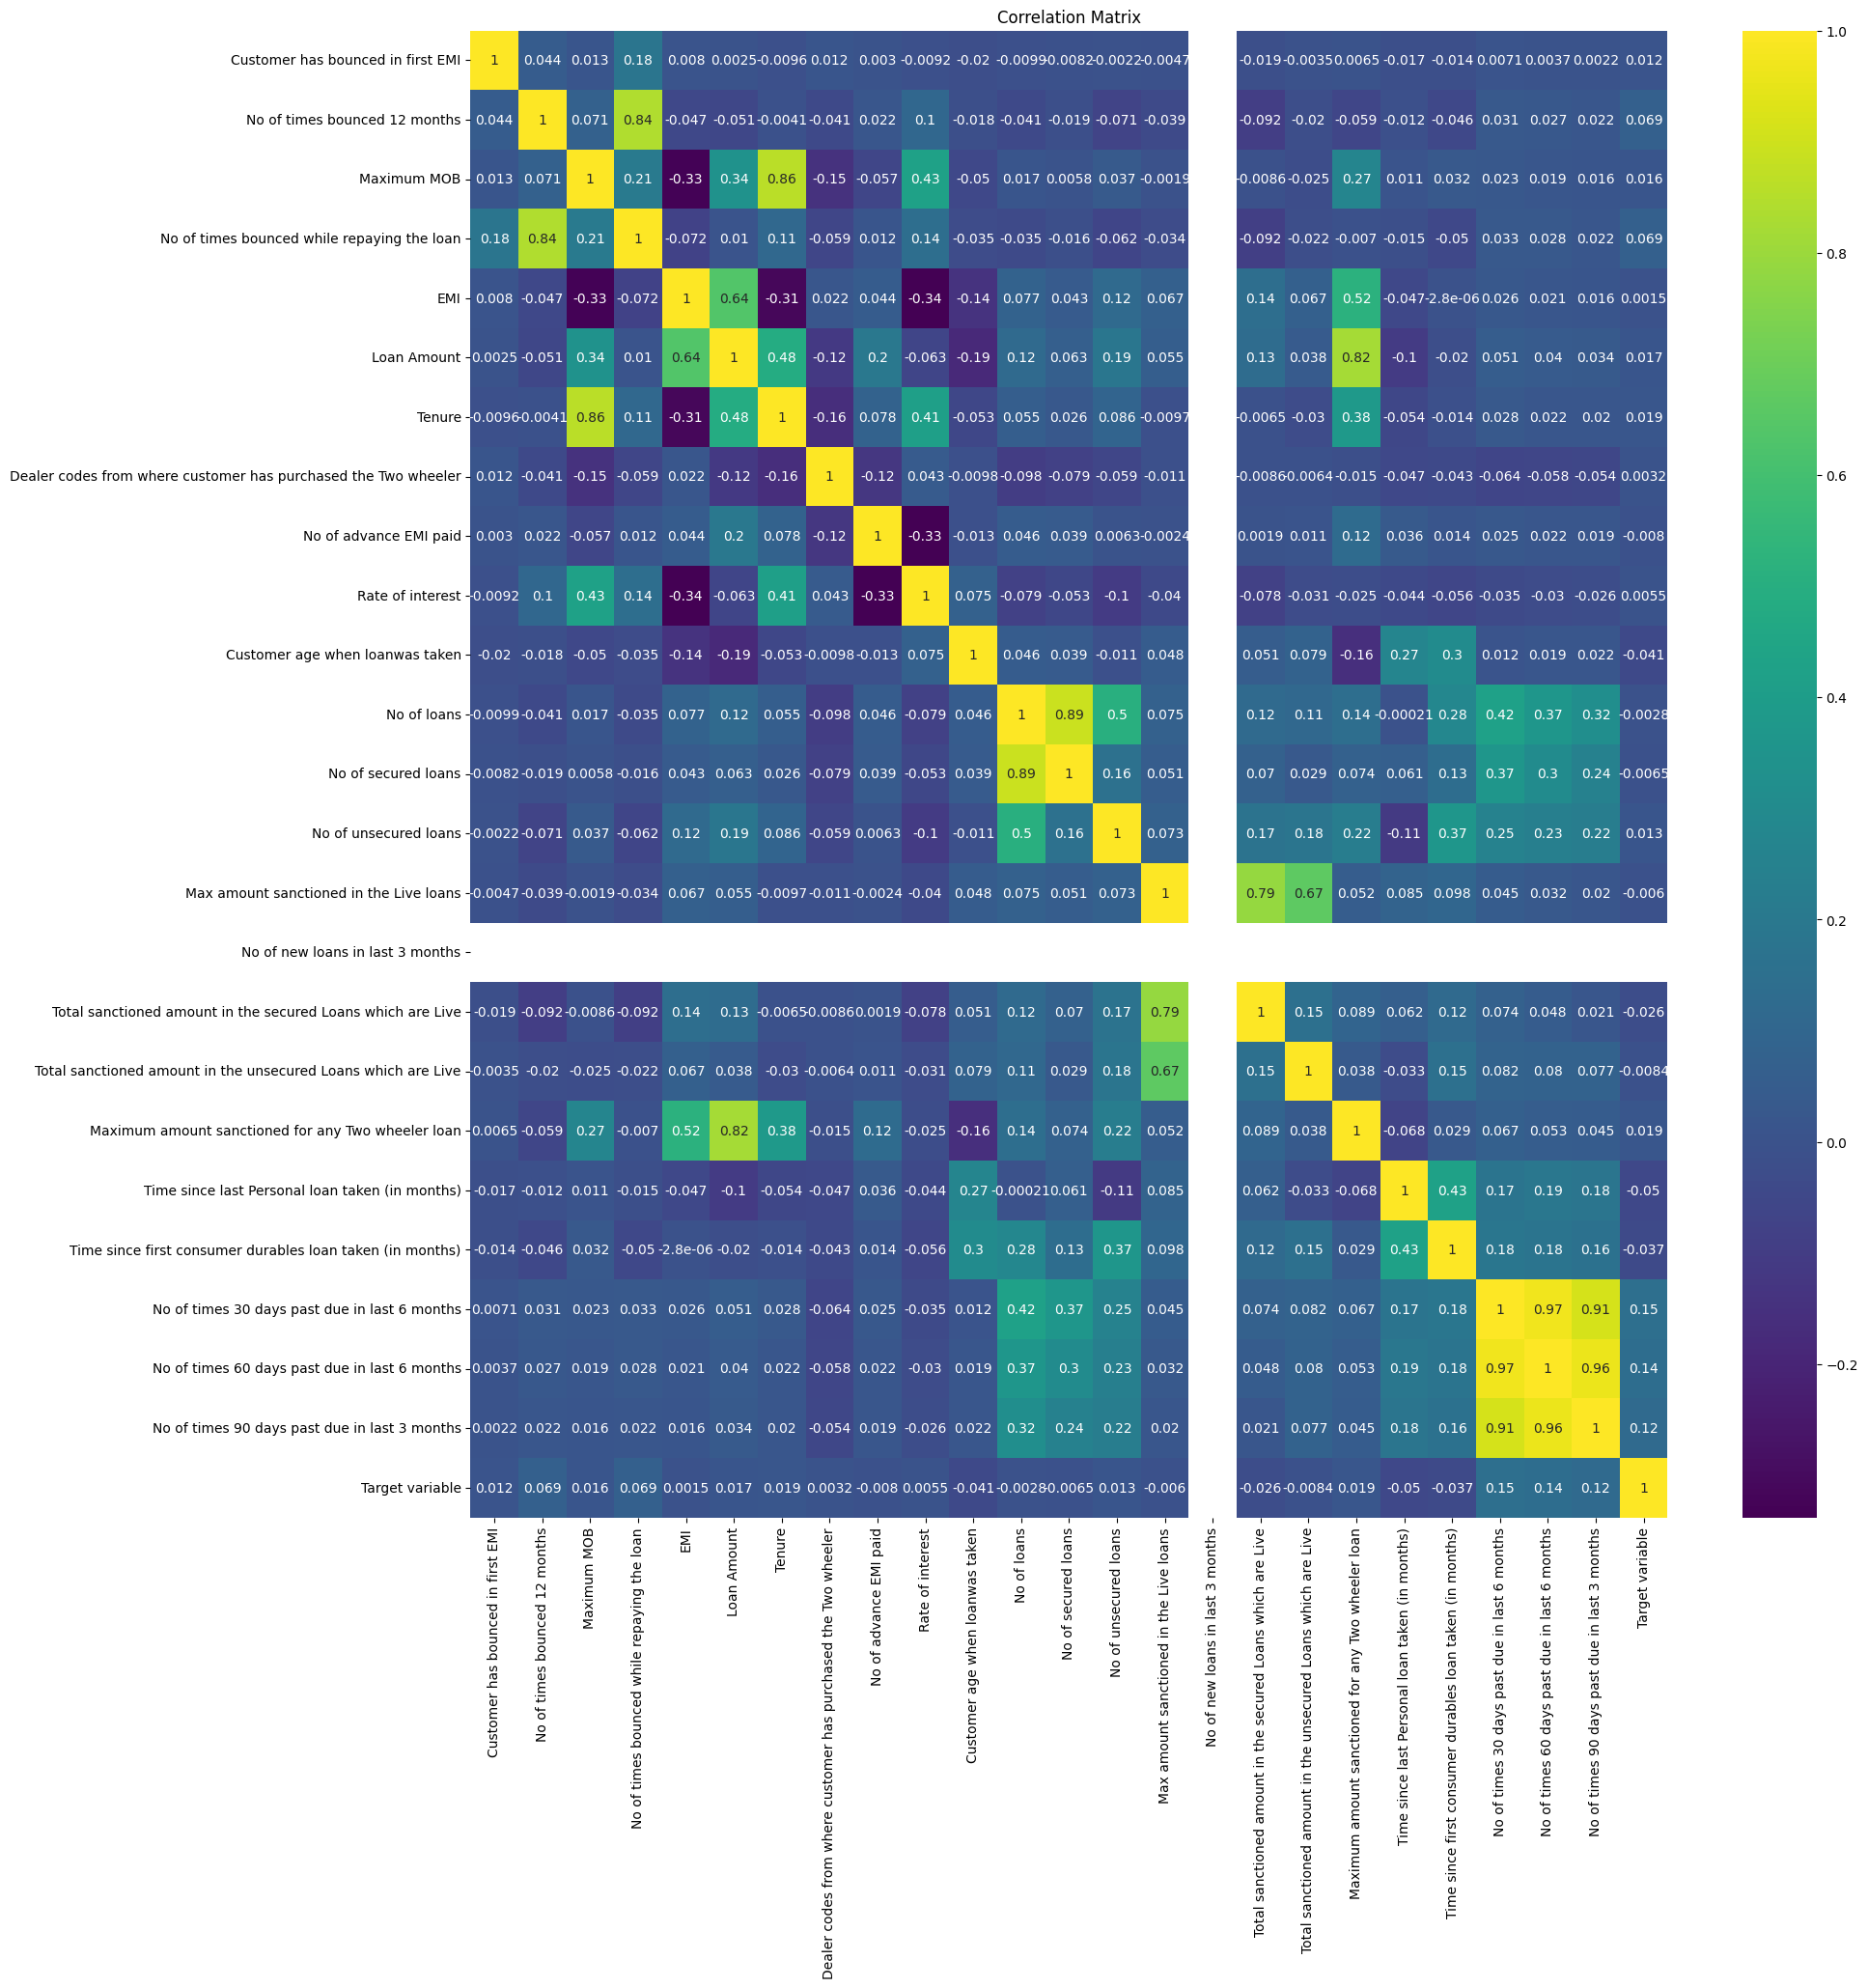

In [11]:
#correlation matrix
corr_mat = Loan_renamed.corr(numeric_only=True)
top_corr_features = corr_mat.index

plt.figure(figsize=(20,20))
sns.heatmap(corr_mat, annot=True, cmap="viridis")
plt.title("Correlation Matrix")
plt.show()

The maximum MOB and tenure are highly correlated and also number of times bounced 12 months and number of times bounced while repaying the loan.
This shows that there is multicollinearity and therefore influences the model we are going to use.

<Axes: title={'center': 'Loan Amount (Box Plot)'}, xlabel='Employment type', ylabel='Loan Amount'>

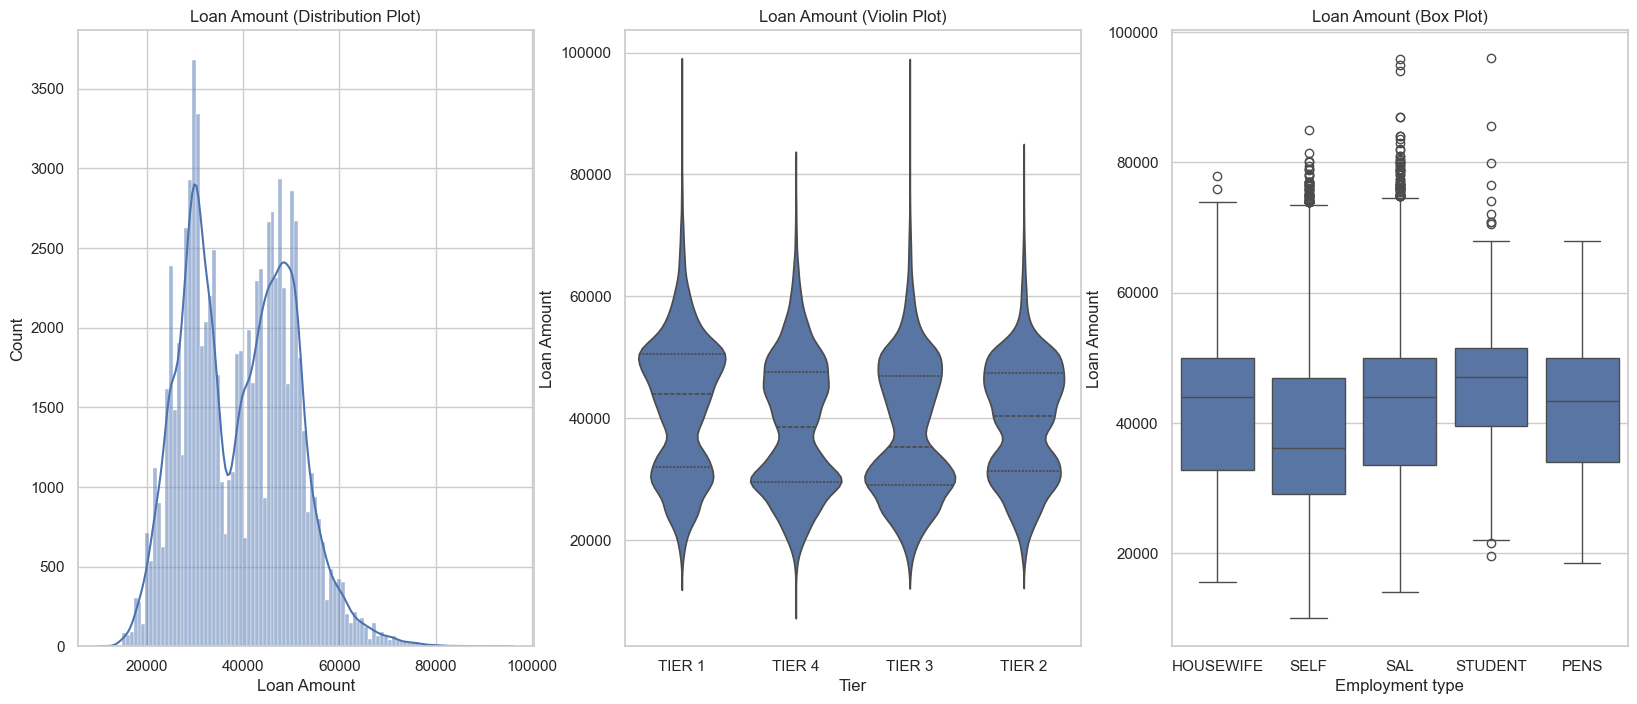

In [12]:
#Loan Amount Visualizations
sns.set(style="whitegrid")

fig, ax=plt.subplots(nrows =1,ncols=3,figsize=(20,8))
ax[0].set_title("Loan Amount (Distribution Plot)")
sns.histplot(Loan_renamed['Loan Amount'], kde=True, ax=ax[0])
ax[1].set_title("Loan Amount (Violin Plot)")
sns.violinplot(data =Loan_renamed, x='Tier',y='Loan Amount',ax=ax[1], inner="quartile")
ax[2].set_title("Loan Amount (Box Plot)")
sns.boxplot(data =Loan_renamed, x='Employment type',y='Loan Amount',ax=ax[2],orient='v')

#### Why Each Loan Amount Plot Matters

##### Distribution Plot (Histogram)
Shows how loan amounts are distributed and this helps identify skewness therefore revealing whether most customers take small or large loans.

The plot is right-skewed meaning that most customers take small loans and few customers take very large loans.

That affects risk modeling.

##### Violin Plot (Loan Amount vs Tier)
Shows distribution across risk tiers.This helps detect whether higher tiers take larger loans.In above violin plot lower tiers i.e tier 1 and 2 take much bigger loans compared to the higher tiers i.e 3 and 4

##### Box Plot (Loan Amount vs Employment Type)
Identifies outliers and also Compares loan size across employment types.Student customers have a higher median loan compared to the others.This means employment type affects borrowing behavior.

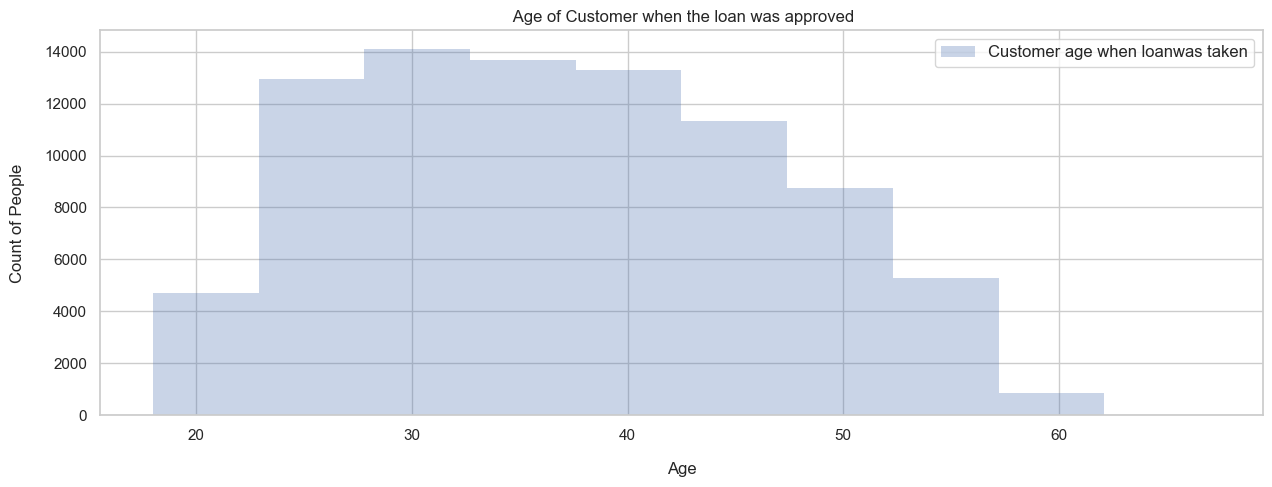

In [13]:
##Age- age at which the client took the loan
plt.figure(figsize=(15,5))

#bar plot
Loan_renamed['Customer age when loanwas taken'].plot(kind='hist',color='b',alpha=0.3, edgecolor='none')
plt.xlabel("Age", labelpad=14)
plt.ylabel("Count of People", labelpad=14)
plt.title(" Age of Customer when the loan was approved")
plt.legend(loc="best",prop={"size":12})

Shows What age group borrows most. Majority of the borrowers are between the age 25-40 and the very few elderly borrowers

<Axes: xlabel='Customer age when loanwas taken', ylabel='Loan Amount'>

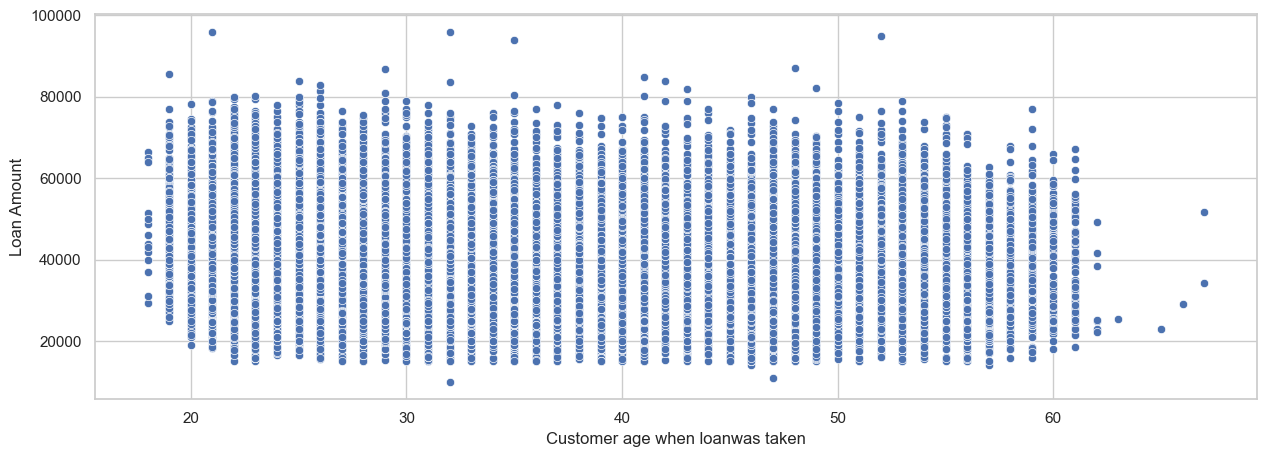

In [14]:
# Explore correlation between age and loan amount 
plt.figure(figsize=(15,5))
sns.scatterplot(x=Loan_renamed['Customer age when loanwas taken'],y='Loan Amount',data=Loan_renamed)


We can see that  younger borrowers take larger loans compared to the older ones.

## 5. DATA CLEANING 

In [15]:
data=Loan_renamed.copy()

In [16]:
# Separate categorical and numerical columns
cat_cols = data.select_dtypes(include=['object']).columns
num_cols = data.select_dtypes(include=['int64','float64']).columns

#standardizing column names for easier usage
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

In [17]:
#Drops rows where loan_amount or gender is missing, because they are critical.
data.dropna(subset=['loan_amount','gender'], inplace=True)

In [18]:
# Impute numerical columns, fill missing values with median (middle value). 
num_imputer = SimpleImputer(strategy='median')
data[num_cols] = num_imputer.fit_transform(data[num_cols])

KeyError: "None of [Index(['Customer has bounced in first EMI', 'No of times bounced 12 months',\n       'Maximum MOB', 'No of times bounced while repaying the loan', 'EMI',\n       'Loan Amount', 'Tenure',\n       'Dealer codes from where customer has purchased the Two wheeler',\n       'No of advance EMI paid', 'Rate of interest',\n       'Customer age when loanwas taken', 'No of loans', 'No of secured loans',\n       'No of unsecured loans', 'Max amount sanctioned in the Live loans',\n       'No of new loans in last 3 months',\n       'Total sanctioned amount in the secured Loans which are Live',\n       'Total sanctioned amount in the unsecured Loans which are Live',\n       'Maximum amount sanctioned for any Two wheeler loan',\n       'Time since last Personal loan taken (in months)',\n       'Time since first consumer durables loan taken (in months)',\n       'No of times 30 days past due in last 6 months',\n       'No of times 60 days past due in last 6 months',\n       'No of t

Median is used instead of mean because it is more robust to outliers

In [ ]:
 #Impute categorical columns
cat_imputer = SimpleImputer(strategy='most_frequent')
data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])

## 6.Encoding Categorical Variables

In [ ]:
le = LabelEncoder()
for col in cat_cols :
    data[col] = le.fit_transform(data[col])

## 7.Handling Imbalanced Data – SMOTE

In [ ]:
X = data.drop(['customer_id','target_variable'], axis=1)
y = data['target_variable']

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

#X = all features (input variables)

#y = target (whether they defaulted)

#SMOTE creates new fake defaulter examples so the model can learn better.

In [ ]:
#Checking that now the number of defaulters and non-defaulters is balanced.
print(y_res.value_counts())

target_variable
0.0    83194
1.0    83194
Name: count, dtype: int64


## 8.Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

In [ ]:
scaler=RobustScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

## 9. Model Training – Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test) #.predict() → model predicts default/non-default for test data

## 10.Model Evaluation

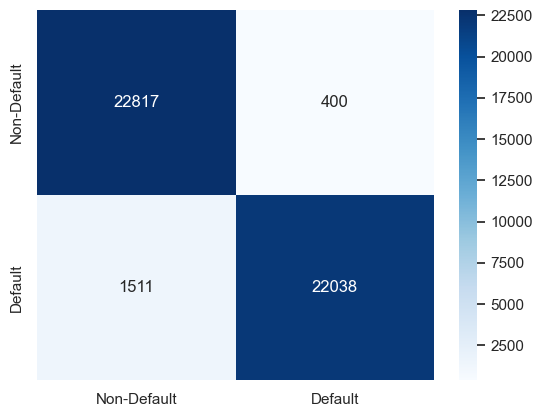

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Default','Default'], yticklabels=['Non-Default','Default'])
plt.show()

In [ ]:
print(classification_report(y_test, y_pred)) #Shows accuracy, precision, recall, F1-score for the model

              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96     23217
         1.0       0.98      0.94      0.96     23549

    accuracy                           0.96     46766
   macro avg       0.96      0.96      0.96     46766
weighted avg       0.96      0.96      0.96     46766



Precision → How many predicted defaulters were actually defaulters

Recall → How many actual defaulters were correctly detected

F1-score → Balance between precision and recall

ROC-AUC → Measures model’s ability to separate classes

The confusion matrix shows that the model performs strongly in predicting both defaulters and non-defaulters. Out of 46,766 observations, the model correctly classified 22,817 non-defaulters and 22,038 defaulters. Only 400 good borrowers were misclassified as defaulters, while 1,511 defaulters were incorrectly predicted as non-defaulters. The model achieved an overall accuracy of approximately 96%, demonstrating high predictive capability. In a credit risk, the model successfully identifies most high-risk borrowers while maintaining a low false rejection rate for good borrowers.

In [ ]:
y_pred_prob = rf.predict_proba(X_test)[:,1]# gives probability of default, not just 0/1
roc = roc_auc_score(y_test, y_pred_prob) #measures how well the model separates defaulters and non-defaulters (higher = better)
print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.992090718301367


## 11.Feature Importance

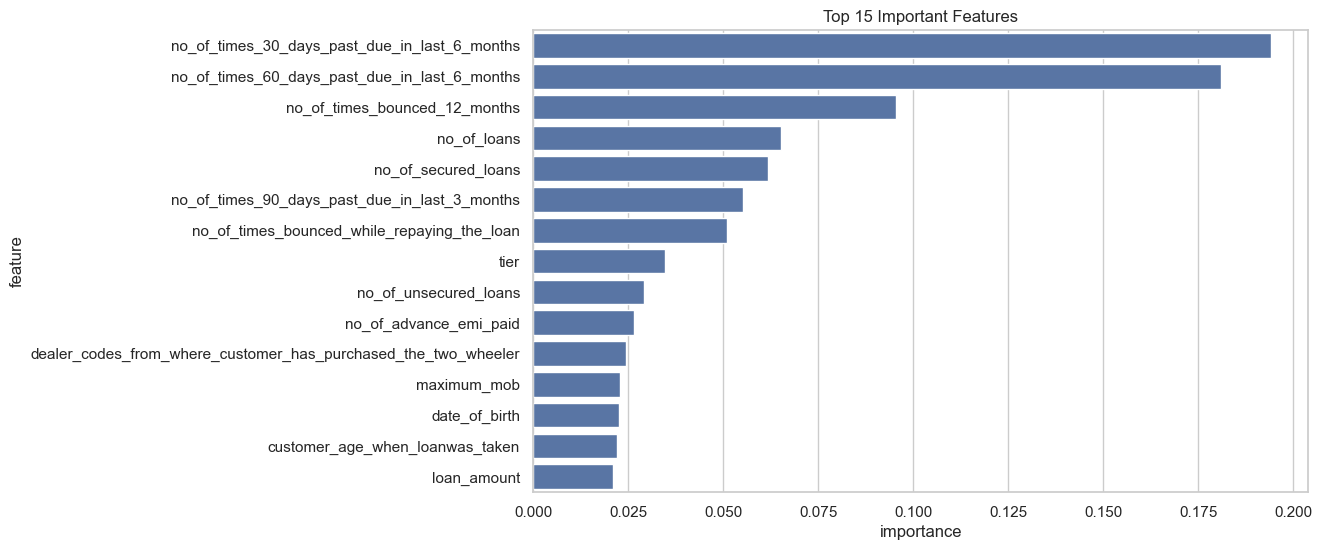

In [ ]:
feature_importances = pd.DataFrame({'feature': X_train.columns, 'importance': rf.feature_importances_})
feature_importances.sort_values(by='importance', ascending=False, inplace=True)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importances.head(15))
plt.title("Top 15 Important Features")
plt.show()

Shows which variables influence default most:


 ## 12. Credit Score Generation


In [ ]:
#credit probalilities to credit scores
# Scale probabilities to 0-1000
# Invert probability (low PD = high score)
credit_scores = (1 - y_pred_prob) * 1000

# Assign categories
def categorize(score):
    if score < 200:
        return "Bad Customer"
    elif score < 350:
        return "2nd Worst"
    elif score < 500:
        return "Not So Bad"
    elif score < 700:
        return "Ideal"
    else:
        return "Big Loans"

credit_category = [categorize(s) for s in credit_scores]

pd.DataFrame({'prob_default': y_pred_prob, 'credit_score': credit_scores, 'category': credit_category}).head(10)

,prob_default,credit_score,category
0,1.000000,0.000000,Bad Customer
1,0.140000,860.000000,Big Loans
2,1.000000,0.000000,Bad Customer
3,0.720000,280.000000,2nd Worst
4,0.990000,10.000000,Bad Customer
5,0.399774,600.225756,Ideal
6,0.040000,960.000000,Big Loans
7,0.960000,40.000000,Bad Customer
8,0.010000,990.000000,Big Loans
9,1.000000,0.000000,Bad Customer
